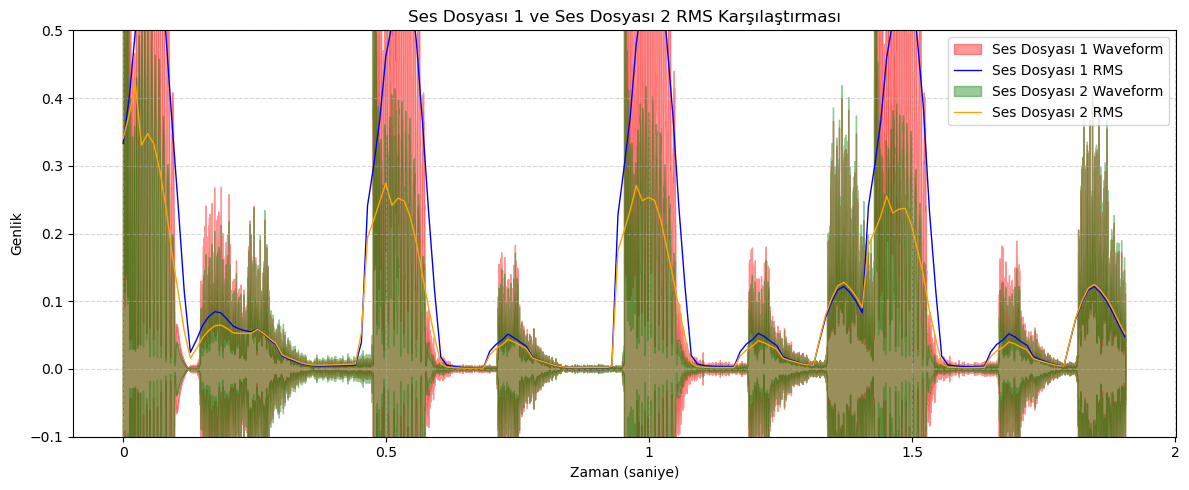

In [32]:
# Gerekli kütüphanelerin içe aktarılması
import matplotlib.pyplot as plt
import numpy as np
import librosa
import librosa.display

# İşlenecek ses dosyalarının yolları
file_1 = "/Users/nazimerensahin/Desktop/1.wav"
file_2 = "/Users/nazimerensahin/Desktop/2.wav"

# İşlenecek ses dosyalarının isimlendirmeleri
label_1 = "Ses Dosyası 1"
label_2 = "Ses Dosyası 2"

# RMS hesaplama fonksiyonu
def compute_rms(y, sr, f_len=2048, hop=512):
    # RMS (Root Mean Square) değeri ve zaman vektörü
    rms = librosa.feature.rms(y=y, frame_length=f_len, 
hop_length=hop)[0]
    time = librosa.times_like(rms, sr=sr, hop_length=hop)
    return rms, time

# Ses dosyalarını yükleme
y1, sr1 = librosa.load(file_1, sr=None)
y2, sr2 = librosa.load(file_2, sr=None)

# RMS değerlerini hesaplama
rms1, t1 = compute_rms(y1, sr1)
rms2, t2 = compute_rms(y2, sr2)

# Grafik çizimi: hem dalga formu hem RMS eğrileri
plt.figure(figsize=(12,5))
librosa.display.waveshow(y1, sr=sr1, alpha=0.4, 
color='red', label=f"{label_1} Waveform")
plt.plot(t1, rms1, color="blue", linewidth=1, 
label=f"{label_1} RMS")

librosa.display.waveshow(y2, sr=sr2, alpha=0.4, 
color='green', label=f"{label_2} Waveform")
plt.plot(t2, rms2, color="orange", linewidth=1, 
label=f"{label_2} RMS")

# Görsel ayarlamalar
plt.title(f"{label_1} ve {label_2} RMS Karşılaştırması")
plt.xlabel("Zaman (saniye)")
plt.ylabel("Genlik")
plt.ylim((-0.1, 0.5))
plt.legend(fontsize=10, loc="upper right")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()